## Load packages


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pylab as pl
import scanpy as sc
from anndata import AnnData
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [ ]:
import FGOT
from FGOT import preprocess as pre
from FGOT import fgot_sparse_tensor, fgot_tol, align
from FGOT import metrics as mt

## Load data


In [ ]:
import pickle

adata_path = "/home/nas3/biod/yangchenghui/proj2/proj2_on_GBM/UniG_result/HumanGBM_UniG_adata_dict.pkl"
with open(adata_path, "rb") as f:
    dict_adata = pickle.load(f)

adata_C = dict_adata["C"]
adata_G = dict_adata["G"]
adata_P = dict_adata["P"]
adata_M = dict_adata["M"]

adata_C, adata_G, adata_P, adata_M


(AnnData object with n_obs × n_vars = 2768 × 50
     obs: 'entity_anno', 'celltype', 'leiden', 'mclust'
     uns: 'neighbors', 'umap', 'leiden', 'leiden_colors', 'mclust_colors', 'celltype_colors'
     obsm: 'spatial', 'X_umap'
     obsp: 'distances', 'connectivities',
 AnnData object with n_obs × n_vars = 1732 × 50
     obs: 'entity_anno',
 AnnData object with n_obs × n_vars = 22692 × 50
     obs: 'entity_anno',
 AnnData object with n_obs × n_vars = 633 × 50
     obs: 'entity_anno')

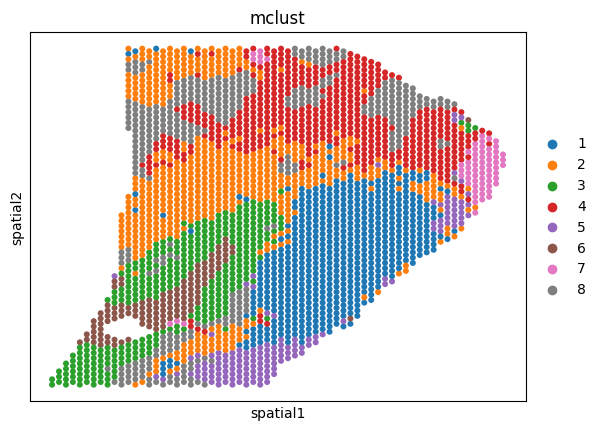

In [ ]:
sc.pl.embedding(
    adata_C,
    basis="spatial",
    color=["mclust"],
    size=75,
)


In [4]:
RNA_cluster = (
    pd.DataFrame(adata_C.obs["mclust"])
    .reset_index()
    .rename(columns={"index": "cell", "mclust": "cluster"})
)
RNA_cluster["cluster"] = RNA_cluster["cluster"].astype(str)
ATAC_cluster = RNA_cluster.copy()
ATAC_cluster


,cell,cluster
0,GCACTGTTGCGGCCTT-1,8
1,GTATCTAGCTACCAGC-1,1
2,CCGGCGAACATCACGT-1,2
3,CGTTACGTGCAGATGG-1,4
4,ATGATATCTAGTCTTA-1,3
...,...,...
2763,ATCACTTAGGCCTTGT-1,4
2764,ATTCTACGTGGCAGAT-1,1
2765,GACTACGCCTATAGCC-1,7
2766,TGAGACTATTGAATCT-1,1


In [5]:
cell_emb = adata_C.copy()
gene_emb = adata_G.copy()
peak_emb = adata_P.copy()
motif_emb = adata_M.copy()

motif_expression_matrix = cell_emb.X @ motif_emb.X.T
peak_expression_matrix = cell_emb.X @ peak_emb.X.T
target_gene_expression_matrix = cell_emb.X @ gene_emb.X.T

adata_motif_expression = AnnData(X=motif_expression_matrix)
adata_motif_expression.obs_names = cell_emb.obs_names
adata_motif_expression.var_names = motif_emb.obs_names
adata_motif_expression.obs["label"] = cell_emb.obs["mclust"].astype(str).values
adata_motif_expression.obsm["spatial"] = cell_emb.obsm["spatial"]

adata_peak_expression = AnnData(X=peak_expression_matrix)
adata_peak_expression.obs_names = cell_emb.obs_names
adata_peak_expression.var_names = peak_emb.obs_names
adata_peak_expression.obs["label"] = cell_emb.obs["mclust"].astype(str).values
adata_peak_expression.obsm["spatial"] = cell_emb.obsm["spatial"]

adata_TG_expression = AnnData(X=target_gene_expression_matrix)
adata_TG_expression.obs_names = cell_emb.obs_names
adata_TG_expression.var_names = gene_emb.obs_names
adata_TG_expression.obs["label"] = cell_emb.obs["mclust"].astype(str).values
adata_TG_expression.obsm["spatial"] = cell_emb.obsm["spatial"]

adata_TG_expression, adata_peak_expression, adata_motif_expression


(AnnData object with n_obs × n_vars = 2768 × 1732
     obs: 'label'
     obsm: 'spatial',
 AnnData object with n_obs × n_vars = 2768 × 22692
     obs: 'label'
     obsm: 'spatial',
 AnnData object with n_obs × n_vars = 2768 × 633
     obs: 'label'
     obsm: 'spatial')

In [ ]:
gene_peak_path = "/home/nas3/biod/yangchenghui/proj2/proj2_on_GBM/SIMBA_result/adata_GenePeak_final.h5ad"
adata_GP = sc.read_h5ad(gene_peak_path)
adata_GP


AnnData object with n_obs × n_vars = 1732 × 22692

In [7]:
feature_matrix = pd.DataFrame(
    data=adata_GP.X.todense(),
    index=adata_GP.obs.index,
    columns=adata_GP.var.index,
).T

# FGOT uses positional arrays, so the feature graph order must match X1/X2.
feature_matrix = feature_matrix.reindex(
    index=adata_peak_expression.var_names,
    columns=adata_TG_expression.var_names,
)

if feature_matrix.index.hasnans or feature_matrix.columns.hasnans:
    raise ValueError("feature_matrix contains NaN feature names after reindexing")

if feature_matrix.isna().any().any():
    missing_peak = feature_matrix.index[feature_matrix.isna().any(axis=1)].tolist()[:5]
    missing_gene = feature_matrix.columns[feature_matrix.isna().any(axis=0)].tolist()[:5]
    raise ValueError(
        "feature_matrix is not compatible with peak/gene expression features. "
        f"Example missing peaks={missing_peak}, missing genes={missing_gene}"
    )

print("feature_matrix aligned:", feature_matrix.shape)
print("peak order matches:", list(feature_matrix.index) == list(adata_peak_expression.var_names))
print("gene order matches:", list(feature_matrix.columns) == list(adata_TG_expression.var_names))
feature_matrix.iloc[:3, :3]


feature_matrix aligned: (22692, 1732)
peak order matches: True
gene order matches: True


,HSPE1,ISLR,CISD1
chr15:42495342-42495842,0,0,0
chr19:5622699-5623199,0,0,0
chr6:3258607-3259107,0,0,0


In [9]:
X1 = adata_peak_expression.X
X2 = adata_TG_expression.X
n1, d1 = X1.shape
n2, d2 = X2.shape

print("Dimensions of input datasets:", "X1 =", X1.shape, "X2 =", X2.shape)

basic_labels1 = np.array(ATAC_cluster["cluster"])
basic_labels2 = np.array(RNA_cluster["cluster"])
print(
    "Dimensions of basic labels:",
    "basic_labels1 =",
    basic_labels1.shape,
    "basic_labels2 =",
    basic_labels2.shape,
)

cell_names1 = list(adata_peak_expression.obs_names)
cell_names2 = list(adata_TG_expression.obs_names)
peak_names = list(adata_peak_expression.var_names)
gene_names = list(adata_TG_expression.var_names)

assert list(feature_matrix.index) == peak_names
assert list(feature_matrix.columns) == gene_names


Dimensions of input datasets are:  X1 =  (2768, 22692)  X2 =  (2768, 1732)
Dimensions of basic_labels are:  basic_labels1 =  (2768,)  basic_labels2 =  (2768,)


## Build a priori feature graph


In [10]:
feature_matrix = feature_matrix.copy()
feature_matrix[feature_matrix == 0] = np.inf
feature_matrix


/tmp/ipykernel_2574849/843364521.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'inf' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  feature_matrix[feature_matrix == 0] = np.inf


,HSPE1,ISLR,CISD1,NLGN3,YWHAE,PKD1,ARF3,HINT1,SPATC1,KLF9,...,ATP6V0D2,PGM2L1,PCDH9,TUFM,RPL35A,RPL36,PIFO,OXA1L,PPIB,DYNLL1
chr15:42495342-42495842,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,...,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf
chr19:5622699-5623199,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,...,inf,inf,inf,inf,inf,1.0,inf,inf,inf,inf
chr6:3258607-3259107,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,...,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf
chr17:63549281-63549781,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,...,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf
chr20:31604969-31605469,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,...,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
chr7:128738344-128738844,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,...,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf
chr12:12704510-12705010,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,...,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf
chr11:62931326-62931826,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,...,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf
chr7:6374151-6374651,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,...,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf


## Compute cost across modalities


In [11]:
adata_graph = adata_C.copy()
n_cells = adata_graph.shape[0]
snn = np.asarray(adata_graph.obsp["connectivities"].todense())
snn[np.arange(n_cells), np.arange(n_cells)] = 1
snn.shape


(2768, 2768)

In [12]:
cost = np.exp(1 - snn)
cost = cost - np.min(cost)
cost = pd.DataFrame(cost, index=adata_C.obs_names, columns=adata_C.obs_names)
cost.head()


,GCACTGTTGCGGCCTT-1,GTATCTAGCTACCAGC-1,CCGGCGAACATCACGT-1,CGTTACGTGCAGATGG-1,ATGATATCTAGTCTTA-1,TCTATTCTGCATTGGC-1,TACACCTTGCGGCAGG-1,CTTGAGTCCAAGGCTG-1,GGACGTCGAACGGCTT-1,CAGCCATGTCTGCCGT-1,...,GACGGTGGTTGATGTC-1,CGCACTGTGAGCCTGT-1,TAGATGGCTGTATGCC-1,TCAAGGTCTGAATATG-1,GAATCATAGTCTGAAG-1,ATCACTTAGGCCTTGT-1,ATTCTACGTGGCAGAT-1,GACTACGCCTATAGCC-1,TGAGACTATTGAATCT-1,GGACGTACATACCAGA-1
GCACTGTTGCGGCCTT-1,0.000000,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282,...,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282
GTATCTAGCTACCAGC-1,1.718282,0.000000,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282,1.456555,1.718282,...,1.718282,1.718282,1.718282,1.012517,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282
CCGGCGAACATCACGT-1,1.718282,1.718282,0.000000,1.718282,1.718282,1.306841,1.718282,1.718282,1.718282,1.718282,...,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282
CGTTACGTGCAGATGG-1,1.718282,1.718282,1.718282,0.000000,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282,...,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282
ATGATATCTAGTCTTA-1,1.718282,1.718282,1.718282,1.718282,0.000000,1.718282,1.718282,1.718282,1.718282,1.718282,...,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282


Text(0.5, 1.0, 'cost across modality')

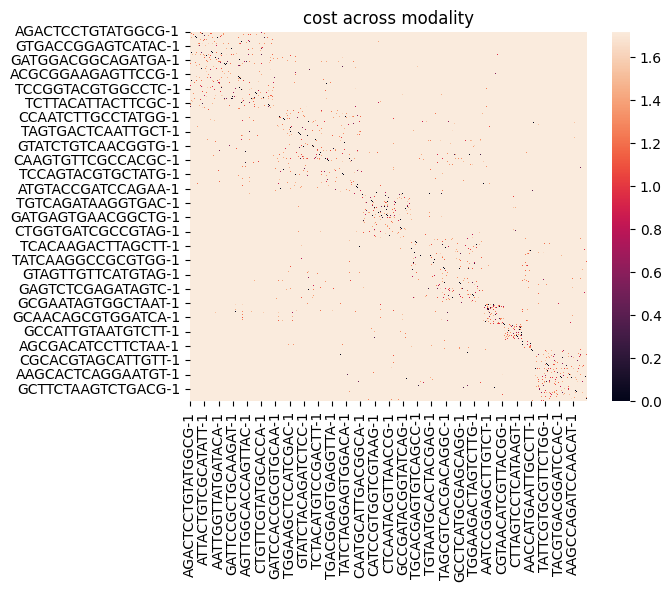

In [13]:
sorted_cols = np.argsort(basic_labels1)
sorted_rows = np.argsort(basic_labels2)
sorted_cost = cost.iloc[sorted_cols, sorted_rows]

sns.heatmap(sorted_cost)
pl.title("Cost across modality")


## Scale


In [14]:
scaler = StandardScaler()
X1 = scaler.fit_transform(X1)
X2 = scaler.fit_transform(X2)

X1 = pd.DataFrame(X1, index=cell_names1, columns=peak_names)
X2 = pd.DataFrame(X2, index=cell_names2, columns=gene_names)


## Solve the feature-guided optimal transport problem


In [ ]:
P_tensor = fgot_sparse_tensor(
    X1,
    X2,
    feature_matrix,
    cost,
    ATAC_cluster,
    RNA_cluster,
    minibatch=1,
    batchsize=250,
    pair=True,
    device="cuda:2",
    eps_p=1e-1,
)

import pickle

p_tensor_path = "/home/nas3/biod/yangchenghui/proj2/proj2_on_GBM/downstream/FGOT_result/P_tensor_GBM.pickle"
with open(p_tensor_path, "wb") as file:
    pickle.dump(P_tensor, file)


In [ ]:
# import pickle

# p_tensor_path = "/home/nas3/biod/yangchenghui/proj2/proj2_on_GBM/downstream/FGOT_result/P_tensor_GBM.pickle"
# with open(p_tensor_path, "rb") as file:
#     P_tensor = pickle.load(file)


## Make multi-omics alignment from the transport tensor


In [18]:
P = fgot_tol(P_tensor)
P.shape

100%|██████████| 40674/40674 [11:47<00:00, 57.50it/s]


(2768, 2768)

In [ ]:
transport_path = "/home/nas3/biod/yangchenghui/proj2/proj2_on_GBM/downstream/FGOT_result/GBM_P_2dim.npy"
np.save(transport_path, P)
# P = np.load(transport_path)


Text(0.5, 1.0, 'optimal transport matrix')

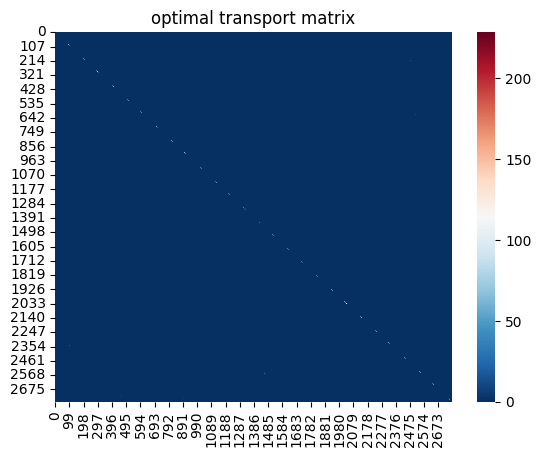

In [ ]:
sns.heatmap(P, cmap="RdBu_r")
pl.title("Optimal transport matrix")


In [21]:
X1_aligned, X2_aligned = align(X1, X2, P, mode="RNA2ATAC")

In [22]:
spatial = np.asarray(adata_C.obsm["spatial"])
data_aligned = np.concatenate((X1_aligned, X2_aligned), axis=0)

adata_aligned = AnnData(data_aligned)
adata_aligned.obs["batch"] = np.array(["ATAC"] * n1 + ["RNA"] * n2)
adata_aligned.obs["label"] = np.concatenate((basic_labels1, basic_labels2), axis=0)
adata_aligned.obsm["spatial"] = np.concatenate((spatial, spatial), axis=0)

sc.tl.pca(adata_aligned)
sc.pp.neighbors(adata_aligned, n_neighbors=15, n_pcs=40)
sc.tl.umap(adata_aligned)


/home/yangchenghui/miniconda3/envs/env_FGOT/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/tmp/ipykernel_2574849/1853092918.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_aligned, key_added='leiden_clusters',resolution=0.4)


[<Axes: title={'center': 'batch'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'label'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'leiden_clusters'}, xlabel='UMAP1', ylabel='UMAP2'>]

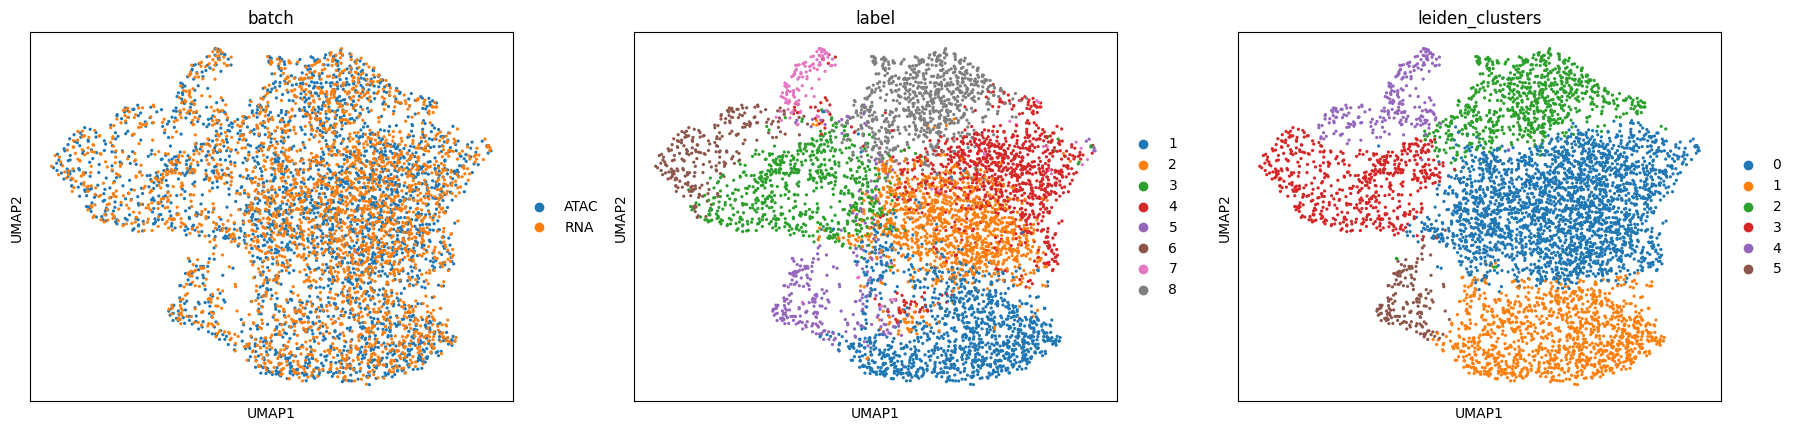

In [23]:
sc.tl.leiden(adata_aligned, key_added="leiden_clusters", resolution=0.4)
sc.pl.umap(
    adata_aligned,
    color=["batch", "label", "leiden_clusters"],
    show=False,
)


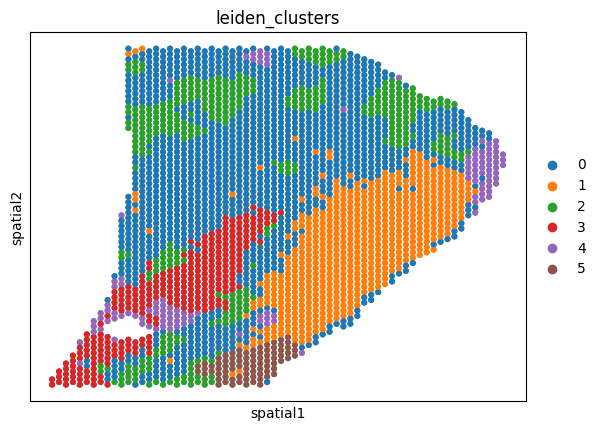

In [24]:
sc.pl.embedding(
    adata_aligned,
    basis="spatial",
    color=["leiden_clusters"],
    size=75,
)


In [ ]:
fgot_adata_path = "/home/nas3/biod/yangchenghui/proj2/proj2_on_GBM/downstream/FGOT_result/GBM_FGOT_adata.h5ad"
adata_aligned.write_h5ad(fgot_adata_path)


# Downstream regulatory analysis


In [ ]:
# import pickle
# with open('/home/nas3/biod/yangchenghui/proj2/proj2_on_GBM/downstream/FGOT_result/P_tensor_GBM.pickle', 'rb') as file:
#     P_tensor = pickle.load(file)

In [29]:
import numpy as np
import pandas as pd
from tqdm import tqdm


def fgot_analysis_link_intensity_for_each_celltype(
    P_tensor,
    feature_matrix,
    cellatac_cluster,
    cellrna_cluster,
    mode="ATAC2RNA",
):
    if mode == "RNA2ATAC":
        feature_matrix = feature_matrix.T

    pairs = {}
    for key in tqdm(list(P_tensor.keys()), desc="Building pairs dictionary"):
        f_i, f_j = (key[0], key[1]) if mode == "RNA2ATAC" else (key[1], key[0])
        pairs.setdefault(f_i, []).append(f_j)

    clusters = sorted(set(cellrna_cluster) & set(cellatac_cluster))
    cellatac_cluster = np.asarray(cellatac_cluster)
    cellrna_cluster = np.asarray(cellrna_cluster)
    cluster_indices_atac = {
        cluster: np.where(cellatac_cluster == cluster)[0]
        for cluster in clusters
    }
    cluster_indices_rna = {
        cluster: np.where(cellrna_cluster == cluster)[0]
        for cluster in clusters
    }

    intensity_tables = []

    for f_i, f_j_list in tqdm(pairs.items(), desc="Processing gene pairs"):
        intensity = np.zeros((len(clusters), len(f_j_list)))

        for j, f_j in enumerate(f_j_list):
            key_j = (f_i, f_j) if mode == "RNA2ATAC" else (f_j, f_i)
            if key_j not in P_tensor:
                continue

            matrix = P_tensor[key_j]
            dense_matrix = matrix.todense() if hasattr(matrix, "todense") else matrix

            for i, cluster in enumerate(clusters):
                index1 = cluster_indices_atac[cluster]
                index2 = cluster_indices_rna[cluster]
                if len(index1) > 0 and len(index2) > 0:
                    intensity[i, j] = dense_matrix[np.ix_(index1, index2)].mean()

        intensity_df = pd.DataFrame(intensity, index=clusters, columns=f_j_list).T
        intensity_df.index = [f"{f_i}-{peak}" for peak in intensity_df.index]
        intensity_tables.append(intensity_df)

    if not intensity_tables:
        return pd.DataFrame()

    return pd.concat(intensity_tables, axis=0)


In [ ]:
intensity_df = fgot_analysis_link_intensity_for_each_celltype(
    P_tensor,
    feature_matrix,
    basic_labels1,
    basic_labels2,
    mode="RNA2ATAC",
)

regulatory_scores_path = "/home/nas3/biod/yangchenghui/proj2/proj2_on_GBM/downstream/FGOT_result/GBM_regulatory_scores.txt"
intensity_df.to_csv(regulatory_scores_path, sep="\t")
intensity_df


Processing gene pairs: 100%|██████████| 22692/22692 [12:46<00:00, 29.62it/s]


,8,6,7,5,2,1,3,4
chr15:42495342-42495842-ZNF106,3.340673e-06,4.101493e-06,0.000153,1.163034e-05,7.122788e-06,1.172599e-06,1.505678e-06,1.304002e-05
chr19:5622699-5623199-RPL36,1.923853e-06,9.171821e-05,0.000001,9.236803e-06,4.975612e-07,2.560059e-06,7.920627e-06,5.849591e-07
chr6:3258607-3259107-TUBB2A,1.180174e-06,9.075393e-07,0.000012,4.221597e-06,2.351703e-06,2.235435e-06,4.319831e-07,1.087495e-06
chr6:3258607-3259107-TUBB2B,9.892942e-07,1.112115e-06,0.000000,6.168058e-06,8.076112e-07,1.792160e-06,1.296800e-07,5.641918e-07
chr17:63549281-63549781-DCAF7,1.913052e-06,4.483355e-05,0.000052,4.739964e-06,3.212180e-06,9.186725e-07,1.740152e-06,2.137042e-06
...,...,...,...,...,...,...,...,...
chr12:12704510-12705010-CDKN1B,3.583497e-06,5.563512e-06,0.000084,2.375811e-06,1.341801e-06,1.676850e-07,1.105576e-06,2.842218e-06
chr11:62931326-62931826-SLC3A2,9.208907e-06,2.748726e-06,0.000007,2.083580e-07,9.049333e-07,2.455163e-08,2.139153e-07,2.234834e-06
chr7:6374151-6374651-KDELR2,4.310975e-06,2.733768e-06,0.000008,4.454373e-06,1.086452e-06,3.287517e-07,3.036394e-06,1.287139e-06
chr7:6374151-6374651-RAC1,6.719290e-06,1.606481e-05,0.000038,6.939667e-06,1.683594e-06,8.051485e-07,4.855500e-06,1.939027e-06


In [32]:
import pandas as pd


def transform_to_unified_df(intensity_df):
    all_data = []
    clusters = intensity_df.columns.tolist()

    for cluster in clusters:
        cluster_data = intensity_df[cluster].reset_index()
        cluster_data.columns = ["peak-gene", "score"]
        cluster_data[["peak", "gene"]] = cluster_data["peak-gene"].str.rsplit(
            "-",
            n=1,
            expand=True,
        )
        cluster_data["celltype"] = cluster
        all_data.append(cluster_data[["gene", "peak", "score", "celltype"]])

    unified_df = pd.concat(all_data, ignore_index=True)
    return unified_df.sort_values(by=["gene", "celltype"])


cluster_dfs = transform_to_unified_df(intensity_df)
cluster_dfs


,gene,peak,score,celltype
232418,A2M,chr12:8914131-8914631,4.215556e-05,1
236608,A2M,chr12:8949774-8950274,2.690481e-06,1
191744,A2M,chr12:8914131-8914631,1.741287e-05,2
195934,A2M,chr12:8949774-8950274,9.925163e-06,2
273092,A2M,chr12:8914131-8914631,2.275706e-06,3
...,...,...,...,...
34979,ZYX,chr7:143381011-143381511,7.325016e-06,8
36332,ZYX,chr7:143287268-143287768,6.908729e-07,8
37440,ZYX,chr7:143375273-143375773,1.454106e-05,8
37528,ZYX,chr7:143362009-143362509,8.193404e-07,8


In [ ]:
regulatory_cluster_path = "/home/nas3/biod/yangchenghui/proj2/proj2_on_GBM/downstream/FGOT_result/GBM_regulatory_cluster.csv"
cluster_dfs.to_csv(regulatory_cluster_path, index=False)
cluster_dfs = pd.read_csv(regulatory_cluster_path)
cluster_dfs


,gene,peak,score,celltype
0,A2M,chr12:8914131-8914631,4.215556e-05,1
1,A2M,chr12:8949774-8950274,2.690481e-06,1
2,A2M,chr12:8914131-8914631,1.741287e-05,2
3,A2M,chr12:8949774-8950274,9.925163e-06,2
4,A2M,chr12:8914131-8914631,2.275706e-06,3
...,...,...,...,...
325387,ZYX,chr7:143381011-143381511,7.325016e-06,8
325388,ZYX,chr7:143287268-143287768,6.908729e-07,8
325389,ZYX,chr7:143375273-143375773,1.454106e-05,8
325390,ZYX,chr7:143362009-143362509,8.193404e-07,8
